In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore

In [2]:
df = pd.read_excel("E:/Coventry Universtiy (CU)/EEST038 - MSc Data Science And Computational Intelligence/2 - 7044SCN - Machine Learning and Statistical Modelling - 2526NOVJAN/Coursework/Food_composition_dataset.xlsx")
df.head()

,FOOD_ID,code,COUNTRY,efsaprodcode2,efsaprodcode2_recoded,level1,level2,level3,NUTRIENT_ID,NUTRIENT_TEXT,UNIT,LEVEL
0,1,A000V,Finland,A000V,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6
1,1,A000V,Sweden,A000V,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6
2,1,A000V,Italy,A000V,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,15.0
3,1,A000V,Germany,A000V,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0
4,1,A000V,France,A000V,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0


In [3]:
df.columns.tolist()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236994 entries, 0 to 236993
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   FOOD_ID                236994 non-null  int64  
 1   code                   236994 non-null  object 
 2   COUNTRY                236994 non-null  object 
 3   efsaprodcode2          236994 non-null  object 
 4   efsaprodcode2_recoded  236994 non-null  object 
 5   level1                 236994 non-null  object 
 6   level2                 236994 non-null  object 
 7   level3                 236994 non-null  object 
 8   NUTRIENT_ID            236994 non-null  int64  
 9   NUTRIENT_TEXT          236994 non-null  object 
 10  UNIT                   236994 non-null  object 
 11  LEVEL                  236994 non-null  float64
dtypes: float64(1), int64(2), object(9)
memory usage: 21.7+ MB


In [4]:
df.describe(include="all")

,FOOD_ID,code,COUNTRY,efsaprodcode2,efsaprodcode2_recoded,level1,level2,level3,NUTRIENT_ID,NUTRIENT_TEXT,UNIT,LEVEL
count,236994.000000,236994,236994,236994,236994,236994,236994,236994,236994.000000,236994,236994,236994.000000
unique,NaN,1350,7,2573,2503,21,72,213,NaN,16,2,NaN
top,NaN,A02NQ,Germany,A037B,"Yoghurt, cow milk, flavoured, QUAL Semi-skimmed",Meat and meat products,Fish,Marine fish (pelagic),NaN,"niacin equivalents, total",Milligram/100 gram,NaN
freq,NaN,1246,35098,190,305,35283,22371,7110,NaN,16751,196364,NaN
mean,18501.018579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6679.562402,NaN,NaN,43.395666
std,11155.370796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7003.645889,NaN,NaN,249.318798
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,0.000000
25%,8936.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.000000,NaN,NaN,0.100000
50%,17919.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,529.000000,NaN,NaN,0.900000
75%,27278.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14176.000000,NaN,NaN,13.740000


In [5]:
df['UNIT'].value_counts()

UNIT
Milligram/100 gram    196364
Microgram/100 gram     40630
Name: count, dtype: int64

In [6]:
df['efsaprodcode2_recoded'].value_counts()

efsaprodcode2_recoded
Yoghurt, cow milk, flavoured, QUAL Semi-skimmed                             305
Yoghurt, cow milk, plain, QUAL Semi-skimmed                                 303
Yoghurt drinks, including sweetened and/or flavoured variants, QUAL Skim    300
Yoghurt, sheep milk, flavoured, QUAL Semi-skimmed                           294
Yoghurt, sheep milk, flavoured, QUAL Skim                                   294
                                                                           ... 
Cheese, comte                                                                 2
Cheese, reblochon                                                             2
Cheese, tomme de savoie                                                       2
Cheese, pont l'eveque                                                         2
Thyme, dry                                                                    1
Name: count, Length: 2503, dtype: int64

In [7]:
df['NUTRIENT_TEXT'].unique()

array(['Calcium (Ca)', 'Total iron', 'Magnesium (Mg)',
       'niacin equivalents, total', 'Phosphorus (P)', 'Potassium (K)',
       'riboflavin', 'Total Selenium', 'thiamin', 'vitamin B-6, total',
       'vitamin B-12',
       'vitamin E; alpha-tocopherol equiv from E vitamer activities',
       'Alpha-tocopherol', 'vitamin K, total', 'Zinc (Zn)', 'Copper (Cu)'],
      dtype=object)

In [8]:
df.isnull().sum()

FOOD_ID                  0
code                     0
COUNTRY                  0
efsaprodcode2            0
efsaprodcode2_recoded    0
level1                   0
level2                   0
level3                   0
NUTRIENT_ID              0
NUTRIENT_TEXT            0
UNIT                     0
LEVEL                    0
dtype: int64

In [9]:
df['level1'].value_counts()

level1
Meat and meat products                                                                      35283
Fish, seafood, amphibians, reptiles and invertebrates                                       34277
Vegetables and vegetable products                                                           32384
Grains and grain-based products                                                             25107
Milk and dairy products                                                                     22932
Fruit and fruit products                                                                    16999
Legumes, nuts, oilseeds and spices                                                          13395
Composite dishes                                                                            12712
Seasoning, sauces and condiments                                                             6271
Sugar, confectionery and water-based sweet desserts                                          5581
Animal and ve

In [10]:
df['NUTRIENT_TEXT'].value_counts()

NUTRIENT_TEXT
niacin equivalents, total                                      16751
Calcium (Ca)                                                   16667
Phosphorus (P)                                                 16608
Potassium (K)                                                  16508
Magnesium (Mg)                                                 16468
riboflavin                                                     16453
Total iron                                                     16426
Zinc (Zn)                                                      16338
thiamin                                                        16208
Copper (Cu)                                                    16189
vitamin B-6, total                                             16165
vitamin B-12                                                   15943
vitamin K, total                                               13691
vitamin E; alpha-tocopherol equiv from E vitamer activities    11359
Total Selenium      

In [11]:
cols_to_drop = ["efsaprodcode2", "code"]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [12]:
df.head()

,FOOD_ID,COUNTRY,efsaprodcode2_recoded,level1,level2,level3,NUTRIENT_ID,NUTRIENT_TEXT,UNIT,LEVEL
0,1,Finland,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6
1,1,Sweden,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6
2,1,Italy,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,15.0
3,1,Germany,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0
4,1,France,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0


In [13]:
def split_food_levels(text):
    if pd.isna(text):
        return ["-", "-", "-", "-"]
    parts = [p.strip() for p in text.split(",")]
    # Ensure exactly 4 parts
    while len(parts) < 4:
        parts.append("-")
    return parts[:4]

df[["foodLevel1", "foodLevel2", "foodLevel3", "foodLevel4"]] = df["efsaprodcode2_recoded"].apply(
    lambda x: pd.Series(split_food_levels(x))
)

In [14]:
# Normalization: convert all units to milligrams (mg)
def convert_to_mg(row):
    if row["UNIT"] == "Microgram/100 gram":
        return row["LEVEL"] / 1000  # convert µg to mg
    else:
        return row["LEVEL"]         # keep mg unchanged

df["LEVEL_MG"] = df.apply(convert_to_mg, axis=1)

In [15]:
print(df["UNIT"].value_counts())
print(df[["LEVEL", "LEVEL_MG"]].head(10))

UNIT
Milligram/100 gram    196364
Microgram/100 gram     40630
Name: count, dtype: int64
   LEVEL  LEVEL_MG
0    9.6       9.6
1    9.6       9.6
2   15.0      15.0
3    8.0       8.0
4    8.0       8.0
5   20.0      20.0
6   20.0      20.0
7    9.5       9.5
8    9.5       9.5
9   17.0      17.0


In [16]:
df.head()

,FOOD_ID,COUNTRY,efsaprodcode2_recoded,level1,level2,level3,NUTRIENT_ID,NUTRIENT_TEXT,UNIT,LEVEL,foodLevel1,foodLevel2,foodLevel3,foodLevel4,LEVEL_MG
0,1,Finland,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6,Popcorn kernels,-,-,-,9.6
1,1,Sweden,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6,Popcorn kernels,-,-,-,9.6
2,1,Italy,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,15.0,Popcorn kernels,-,-,-,15.0
3,1,Germany,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0,Popcorn kernels,-,-,-,8.0
4,1,France,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0,Popcorn kernels,-,-,-,8.0


In [17]:
def clean_nutrient_text(text):
    if pd.isna(text):
        return text
    # Remove parentheses content: "Calcium (Ca)" → "Calcium"
    text = text.split("(")[0].strip()
    # Title case: "calcium" → "Calcium"
    text = text.title()
    return text

df["NUTRIENT_TEXT_CLEAN"] = df["NUTRIENT_TEXT"].apply(clean_nutrient_text)

In [18]:
df.head()

,FOOD_ID,COUNTRY,efsaprodcode2_recoded,level1,level2,level3,NUTRIENT_ID,NUTRIENT_TEXT,UNIT,LEVEL,foodLevel1,foodLevel2,foodLevel3,foodLevel4,LEVEL_MG,NUTRIENT_TEXT_CLEAN
0,1,Finland,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6,Popcorn kernels,-,-,-,9.6,Calcium
1,1,Sweden,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,9.6,Popcorn kernels,-,-,-,9.6,Calcium
2,1,Italy,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,15.0,Popcorn kernels,-,-,-,15.0,Calcium
3,1,Germany,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0,Popcorn kernels,-,-,-,8.0,Calcium
4,1,France,Popcorn kernels,Grains and grain-based products,Cereals and similar,Cereal and cereal-like grains,56,Calcium (Ca),Milligram/100 gram,8.0,Popcorn kernels,-,-,-,8.0,Calcium


In [19]:
pivot = df.pivot_table(
    index="efsaprodcode2_recoded",   # pivot by food item
    columns="NUTRIENT_TEXT_CLEAN",   # each nutrient becomes a column
    values="LEVEL_MG",                   # nutrient level becomes value
    aggfunc="mean",                   # if duplicates exist
    fill_value=0                      # fill missing nutrients with zero
)

pivot.reset_index(inplace=True)

In [20]:
meta_cols = [
    "efsaprodcode2_recoded",
    "foodLevel1", "foodLevel2", "foodLevel3", "foodLevel4",
    "level1", "level2", "level3"    # keep if needed
]

meta = df[meta_cols].drop_duplicates(subset="efsaprodcode2_recoded")

final_df = pivot.merge(meta, on="efsaprodcode2_recoded", how="left")

In [21]:
categorical_cols = [
    "foodLevel1", "foodLevel2", "foodLevel3", "foodLevel4",
    "level1", "level2", "level3"
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    final_df[col] = le.fit_transform(final_df[col].astype(str))
    label_encoders[col] = le

In [22]:
print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (2503, 24)


,efsaprodcode2_recoded,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,...,Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities,"Vitamin K, Total",Zinc,foodLevel1,foodLevel2,foodLevel3,foodLevel4,level1,level2,level3
0,Acidophilus milk,0.089,122.571429,0.0070,11.600000,0.957143,95.428571,153.428571,0.181429,0.033286,...,0.223333,0.001,0.428571,0,0,0,0,14,25,146
1,"Acidophilus milk, QUAL Semi-skimmed",0.037,109.228571,0.0460,10.228571,0.690000,84.428571,138.428571,0.161143,0.027571,...,0.022333,0.000,0.387143,0,25,0,0,14,25,146
2,"Acidophilus milk, QUAL Skim",0.000,117.285714,0.0052,12.285714,0.712000,93.857143,149.714286,0.173714,0.034857,...,0.090000,0.000,0.418571,0,26,0,0,14,25,146
3,Alcoholic sweet sauce,0.865,26.000000,0.0840,7.000000,0.956000,95.000000,65.000000,0.087000,0.037000,...,0.865000,0.002,0.711000,1,0,0,0,16,18,47
4,Alcopop and flavoured wine,0.000,4.200000,0.0310,1.000000,0.000000,6.000000,2.600000,0.000000,0.000000,...,0.000000,0.000,0.014000,2,0,0,0,1,45,117


In [23]:
final_df.columns.tolist()

['efsaprodcode2_recoded',
 'Alpha-Tocopherol',
 'Calcium',
 'Copper',
 'Magnesium',
 'Niacin Equivalents, Total',
 'Phosphorus',
 'Potassium',
 'Riboflavin',
 'Thiamin',
 'Total Iron',
 'Total Selenium',
 'Vitamin B-12',
 'Vitamin B-6, Total',
 'Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities',
 'Vitamin K, Total',
 'Zinc',
 'foodLevel1',
 'foodLevel2',
 'foodLevel3',
 'foodLevel4',
 'level1',
 'level2',
 'level3']

In [24]:
nutrient_columns = [
    col for col in final_df.columns
    if col not in ["efsaprodcode2_recoded", "foodLevel1", "foodLevel2", 
                   "foodLevel3", "foodLevel4", "level1", "level2", "level3"]
]

X = final_df[nutrient_columns + categorical_cols]

print("Final dataframe shape (with food names):", final_df.shape)
print("ML feature matrix shape (numeric only):", X.shape)

Final dataframe shape (with food names): (2503, 24)
ML feature matrix shape (numeric only): (2503, 23)


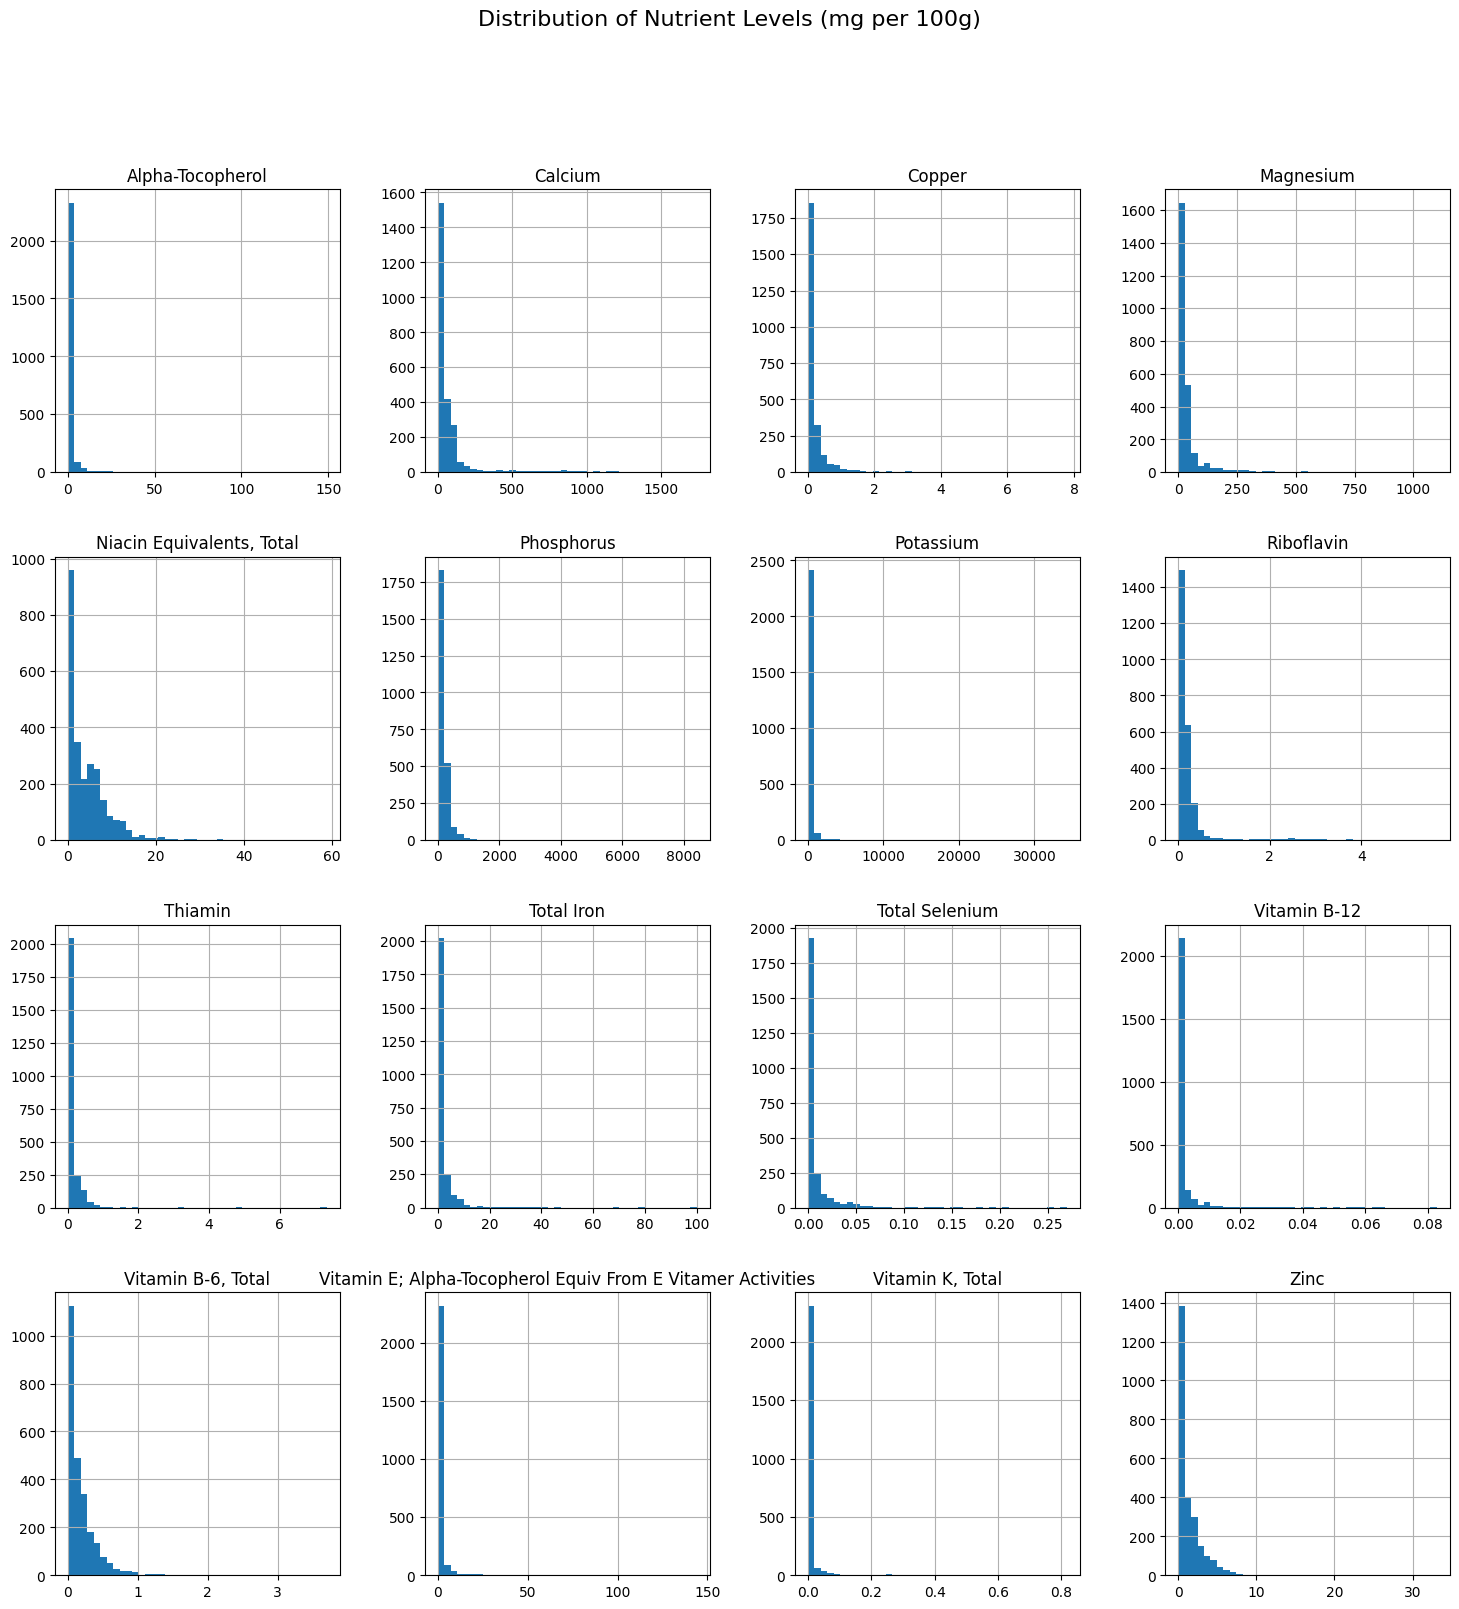

In [ ]:

# Plot histograms for all nutrients (ignore categorical foodLevel columns)
numeric_nutrients = final_df[nutrient_columns]

numeric_nutrients.hist(bins=40, figsize=(18, 18))
plt.suptitle("Distribution of Nutrient Levels (mg per 100g)", fontsize=16)
plt.show()

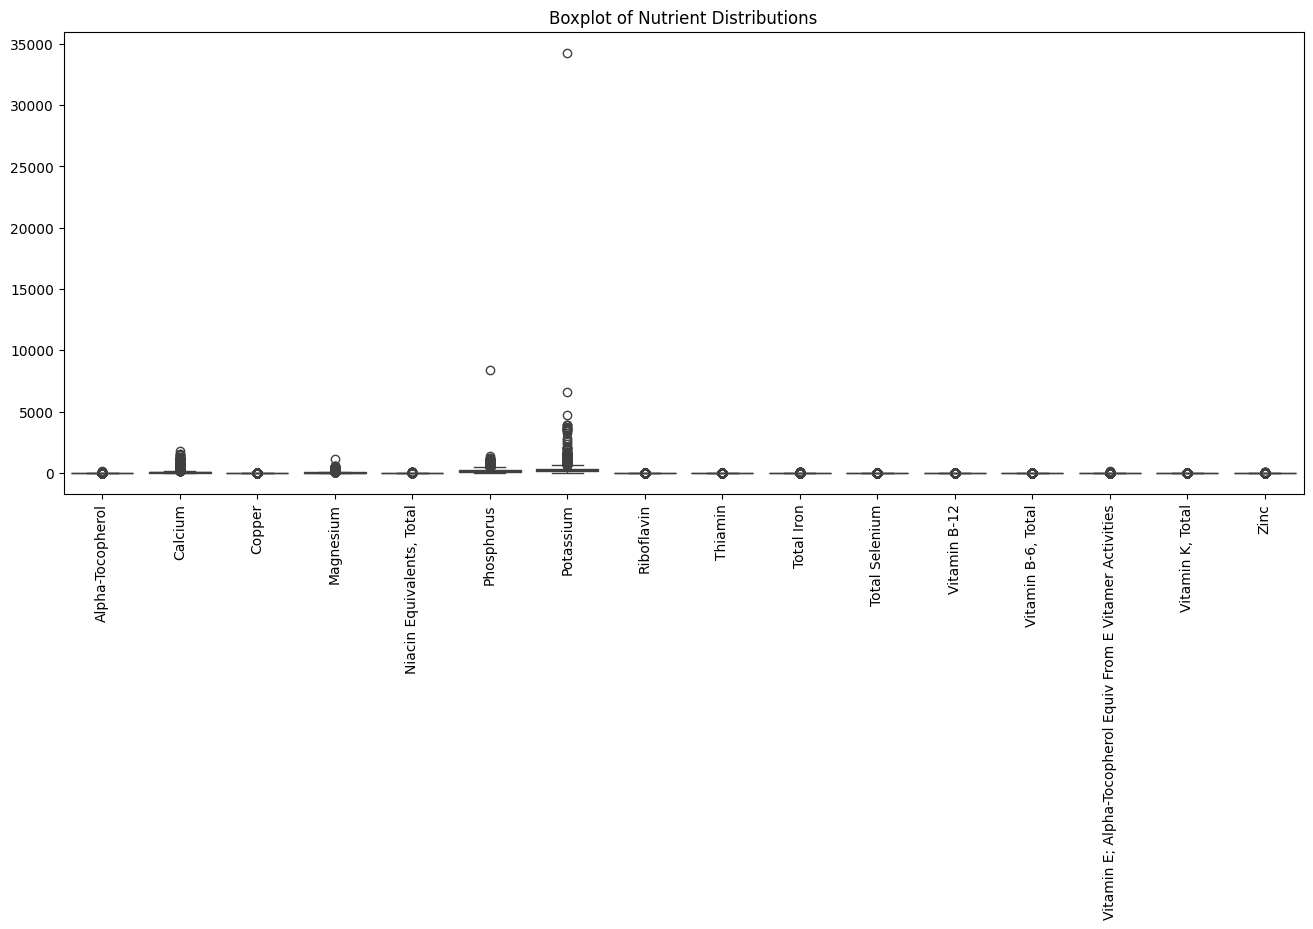

In [26]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=numeric_nutrients)
plt.xticks(rotation=90)
plt.title("Boxplot of Nutrient Distributions")
plt.show()

In [27]:
# Duplicate dataframe
final_df_zscore = final_df.copy()

# Calculate Z-scores for the selected columns
z_scores = zscore(final_df_zscore[nutrient_columns])

# Find rows where Z-score > 3 or <-3 (outliers)
outliers_z = (abs(z_scores) > 3).any(axis=1)

# Filter out rows with outliers based on Z-score
final_df_no_outliers_z = final_df_zscore[~outliers_z]

print(f"Number of rows affected by outliers (Z-score > 3 or < -3): {outliers_z.sum()}")

Number of rows affected by outliers (Z-score > 3 or < -3): 362


In [28]:
final_df_no_outliers_z.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2141 entries, 0 to 2502
Data columns (total 24 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   efsaprodcode2_recoded                                        2141 non-null   object 
 1   Alpha-Tocopherol                                             2141 non-null   float64
 2   Calcium                                                      2141 non-null   float64
 3   Copper                                                       2141 non-null   float64
 4   Magnesium                                                    2141 non-null   float64
 5   Niacin Equivalents, Total                                    2141 non-null   float64
 6   Phosphorus                                                   2141 non-null   float64
 7   Potassium                                                    2141 non-null   float6

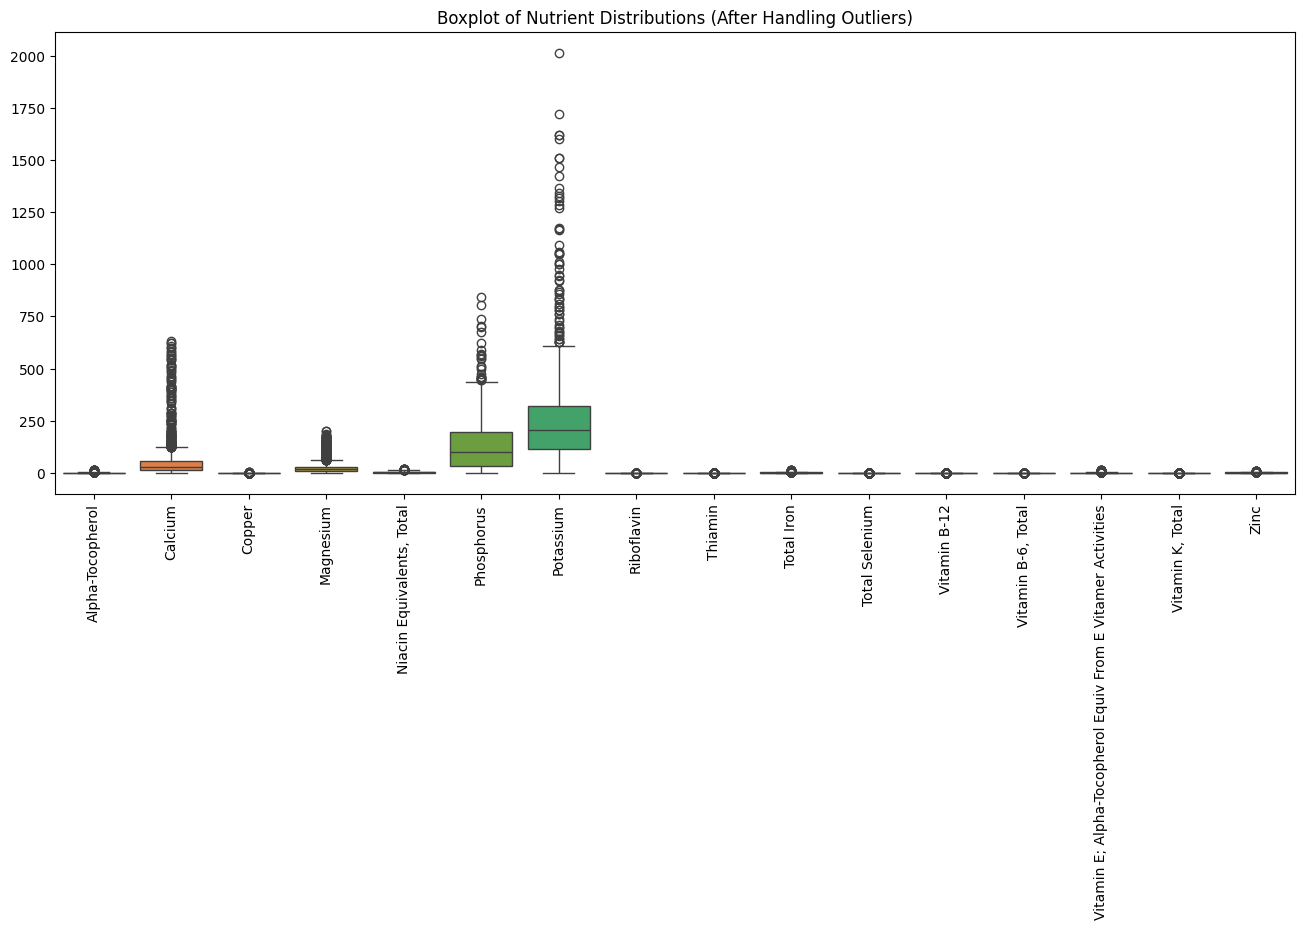

In [29]:
# Plot the boxplot after handling outliers
plt.figure(figsize=(16, 6))
sns.boxplot(data=final_df_no_outliers_z[nutrient_columns])
plt.xticks(rotation=90)
plt.title("Boxplot of Nutrient Distributions (After Handling Outliers)")
plt.show()

In [30]:
# Duplicate dataframe
final_df_IQR = final_df.copy()

# Calculate the IQR for each column
Q1 = final_df_IQR[nutrient_columns].quantile(0.25)
Q3 = final_df_IQR[nutrient_columns].quantile(0.75)
IQR = Q3 - Q1

# Find rows that are outliers based on IQR
outliers_iqr = ((final_df_IQR[nutrient_columns] < (Q1 - 1.5 * IQR)) | (final_df_IQR[nutrient_columns] > (Q3 + 1.5 * IQR)))

# Filter out rows with outliers based on IQR
final_df_no_outliers_iqr = final_df_IQR[~outliers_iqr.any(axis=1)]

print(f"Number of rows affected by outliers (IQR): {outliers_iqr.sum()}")

Number of rows affected by outliers (IQR): Alpha-Tocopherol                                               253
Calcium                                                        227
Copper                                                         276
Magnesium                                                      265
Niacin Equivalents, Total                                       68
Phosphorus                                                     122
Potassium                                                      132
Riboflavin                                                     161
Thiamin                                                        282
Total Iron                                                     261
Total Selenium                                                 329
Vitamin B-12                                                   269
Vitamin B-6, Total                                             153
Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities    272
Vitamin K, Total   

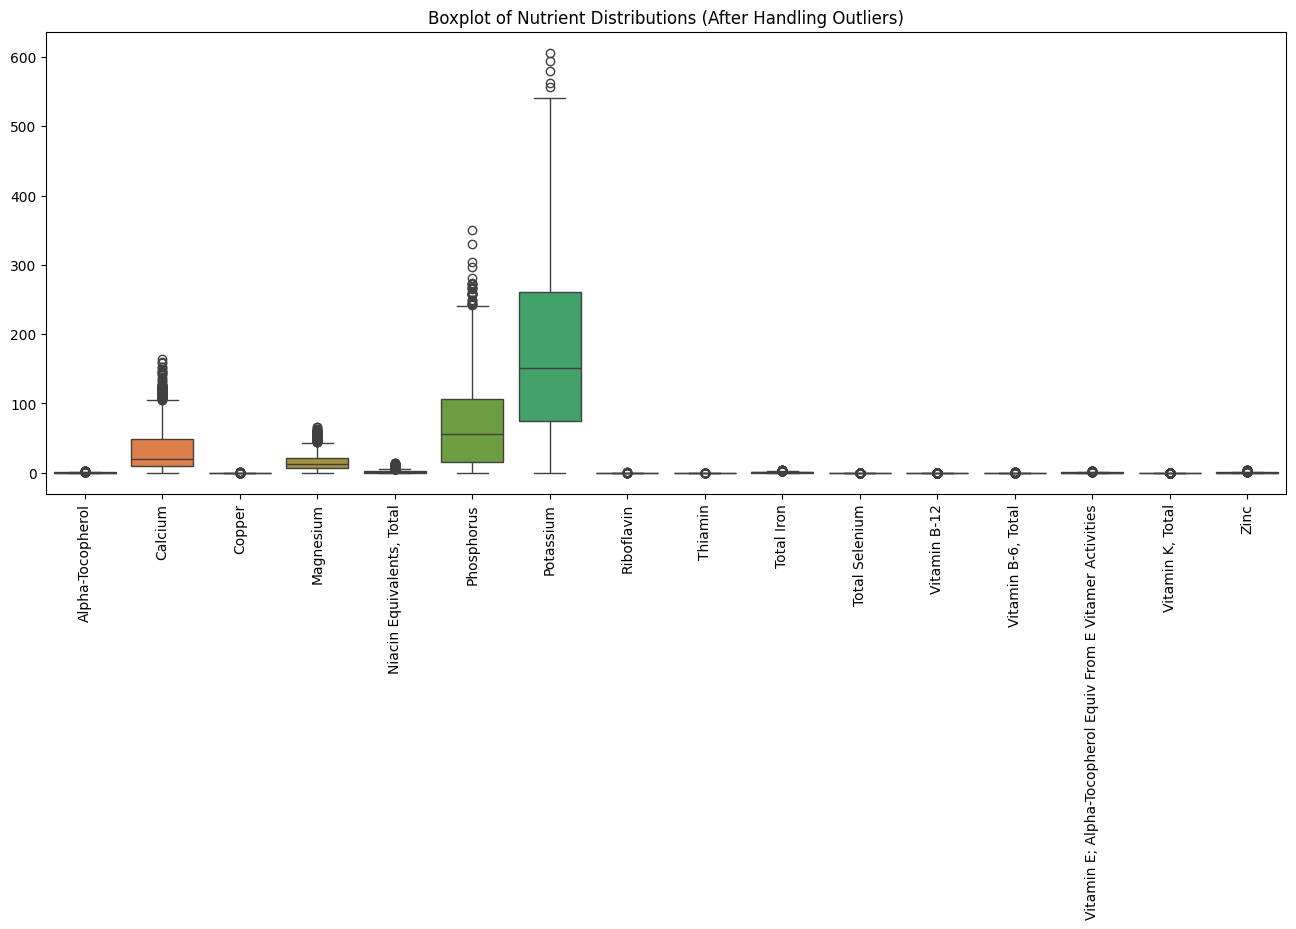

In [31]:
# Plot the boxplot after handling outliers
plt.figure(figsize=(16, 6))
sns.boxplot(data=final_df_no_outliers_iqr[nutrient_columns])
plt.xticks(rotation=90)
plt.title("Boxplot of Nutrient Distributions (After Handling Outliers)")
plt.show()

In [32]:
# Apply capping/flooring (clip values to the 5th and 95th percentiles)
final_df[nutrient_columns] = final_df[nutrient_columns].apply(
    lambda x: x.clip(lower=x.quantile(0.05), upper=x.quantile(0.95))
)

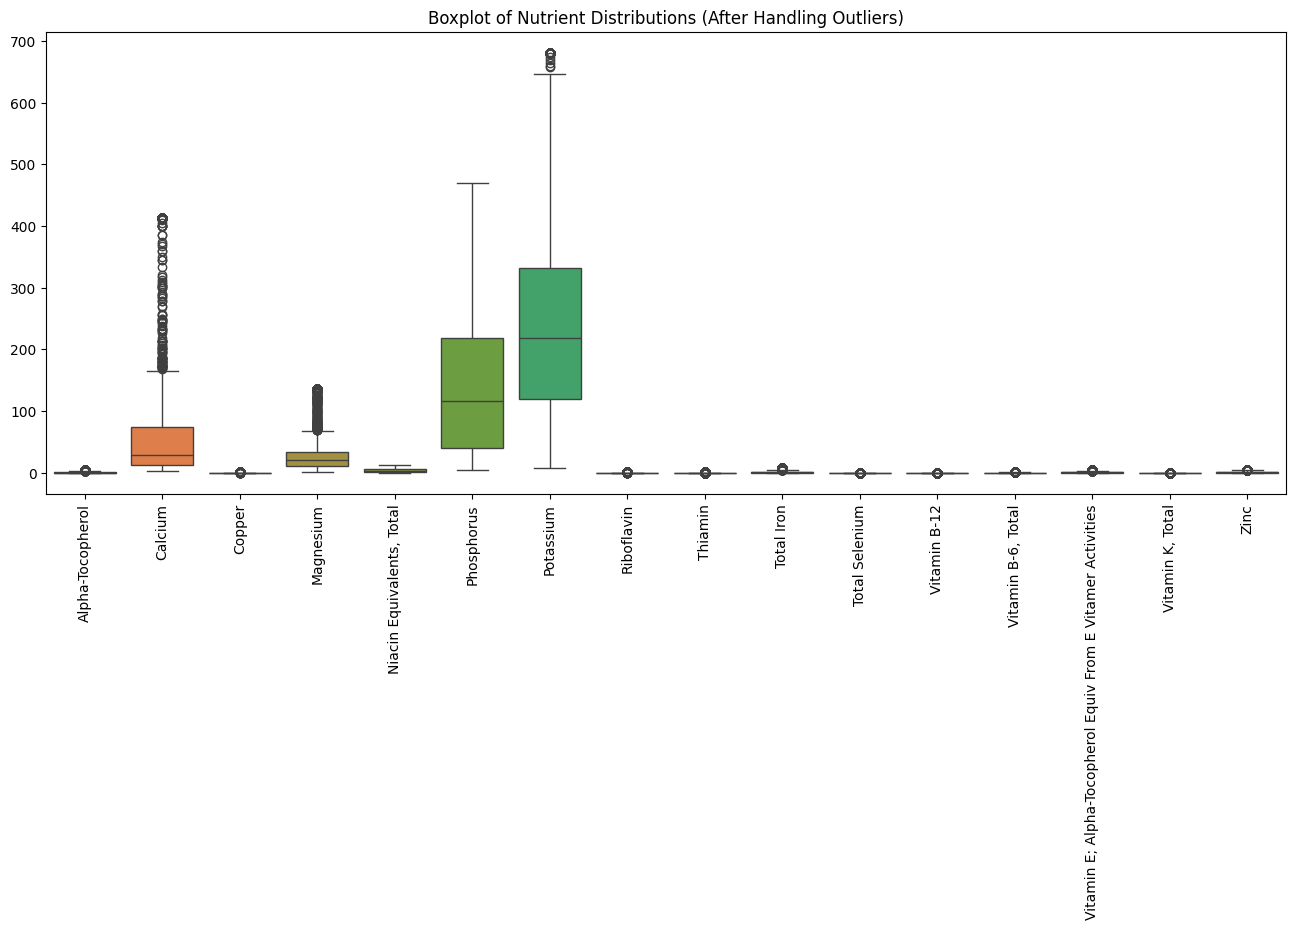

In [33]:
# Plot the boxplot after handling outliers
plt.figure(figsize=(16, 6))
sns.boxplot(data=final_df[nutrient_columns])
plt.xticks(rotation=90)
plt.title("Boxplot of Nutrient Distributions (After Handling Outliers)")
plt.show()

In [34]:
# Apply log transformation (handling zeros by using log1p)
final_df[nutrient_columns] = final_df[nutrient_columns].apply(lambda x: np.log1p(x))

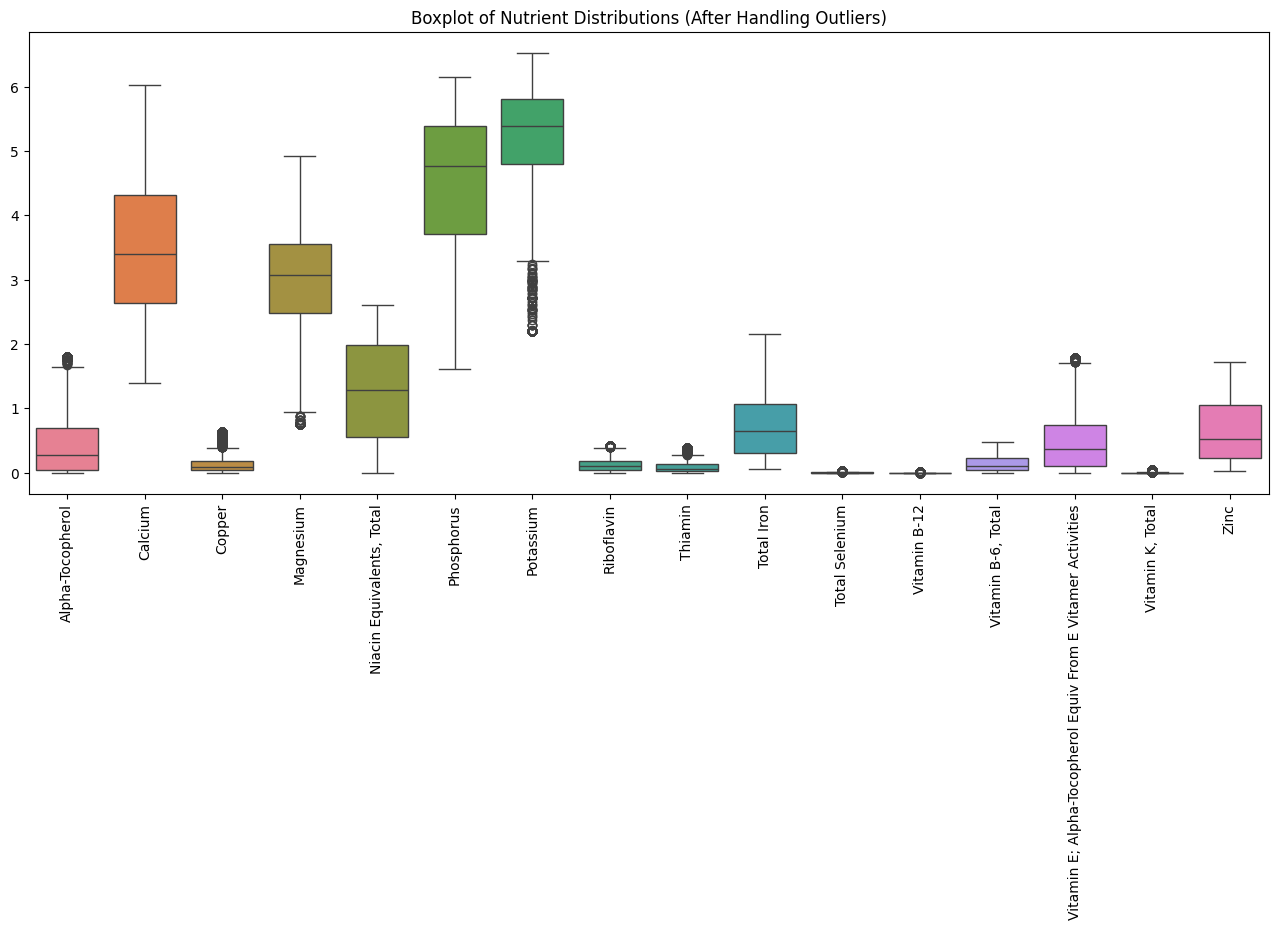

In [35]:
# Plot the boxplot after handling outliers
plt.figure(figsize=(16, 6))
sns.boxplot(data=final_df[nutrient_columns])
plt.xticks(rotation=90)
plt.title("Boxplot of Nutrient Distributions (After Handling Outliers)")
plt.show()

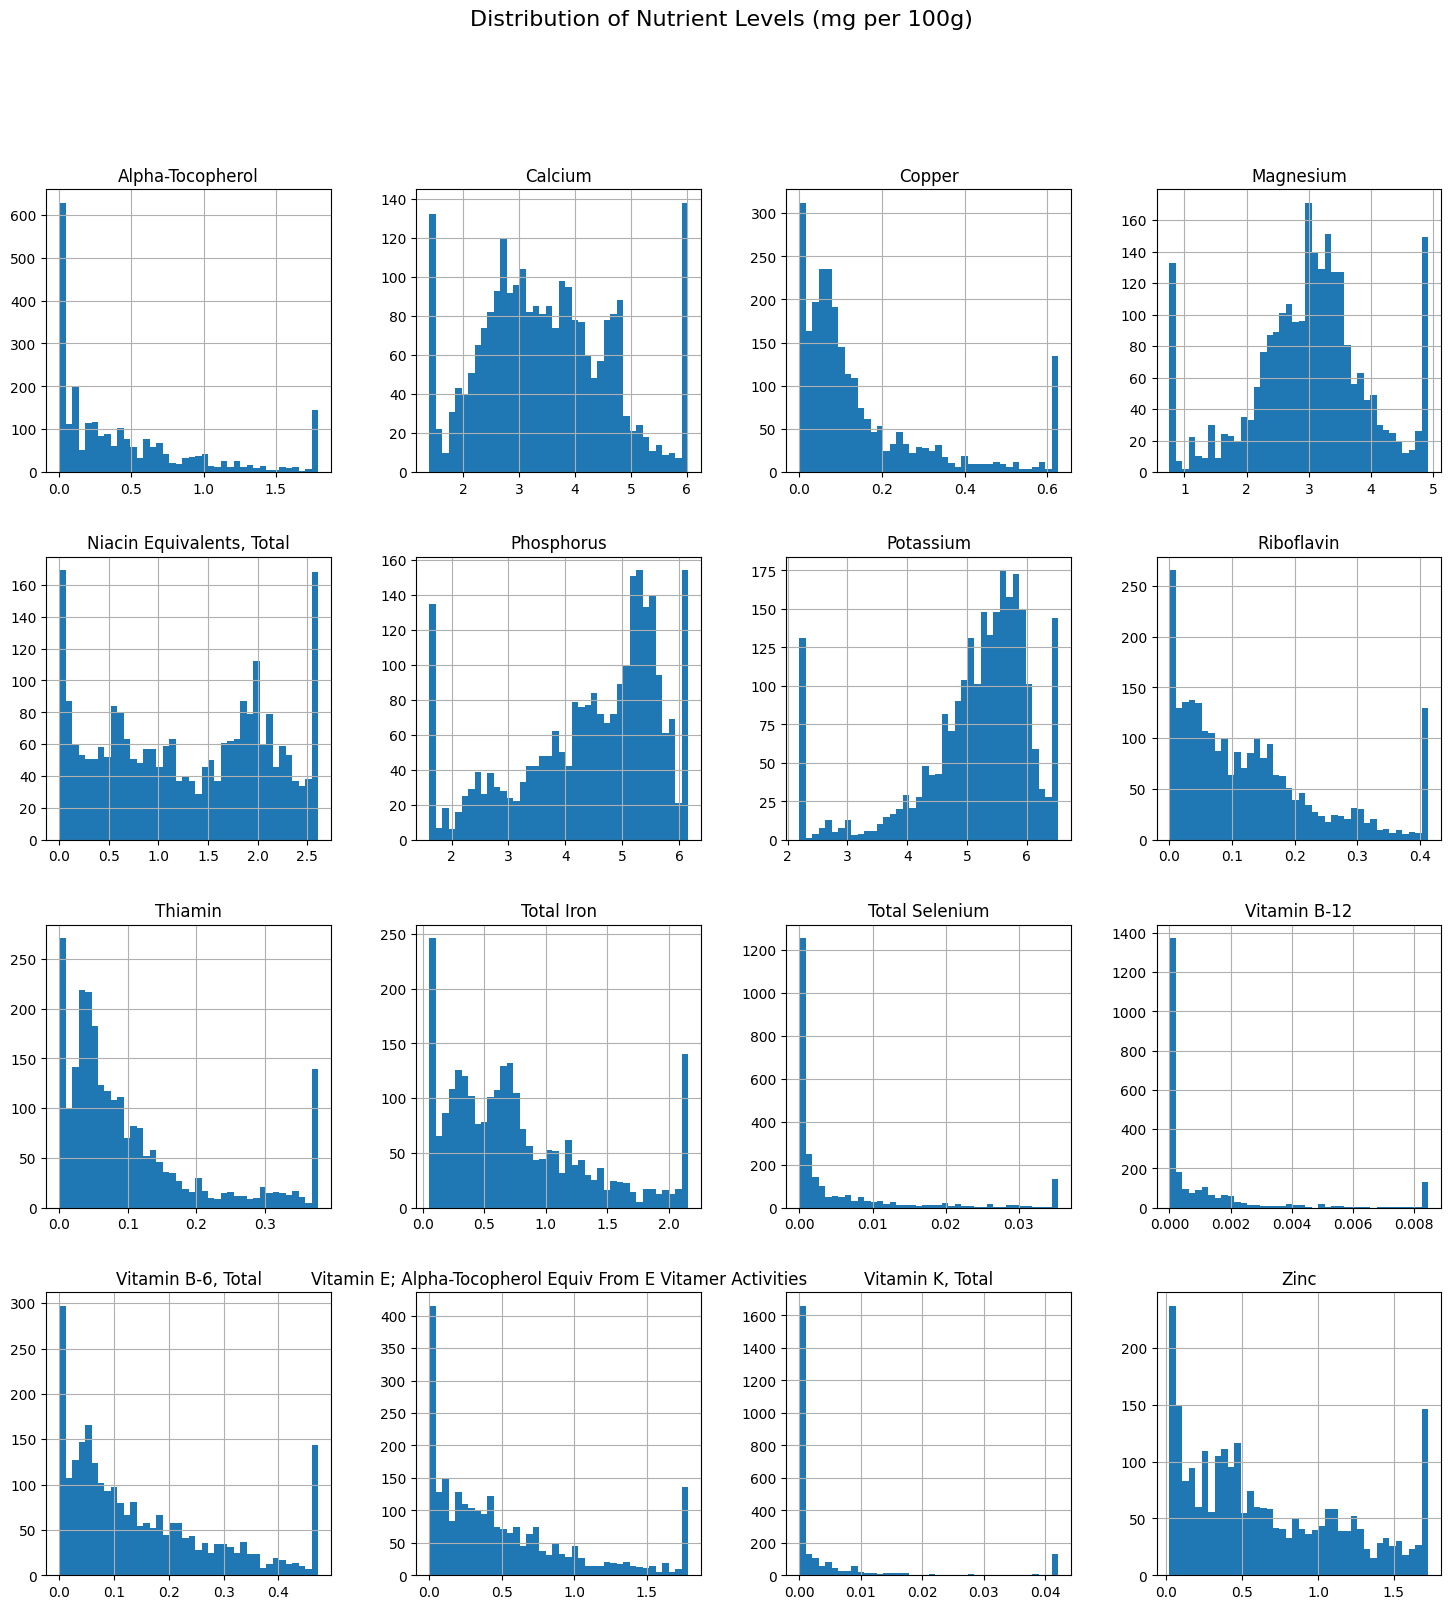

In [50]:
# Plot histograms for all nutrients (ignore categorical foodLevel columns)
numeric_nutrients = final_df[nutrient_columns]

numeric_nutrients.hist(bins=40, figsize=(18, 18))
plt.suptitle("Distribution of Nutrient Levels (mg per 100g)", fontsize=16)
plt.show()

In [36]:
# Assuming 'categorical_cols' are the columns for categorical variables
X = final_df[nutrient_columns + categorical_cols]

print("Final dataframe shape (after preprocessing):", final_df.shape)
print("ML feature matrix shape (numeric only):", X.shape)

Final dataframe shape (after preprocessing): (2503, 24)
ML feature matrix shape (numeric only): (2503, 23)


In [37]:
X.columns.tolist()

['Alpha-Tocopherol',
 'Calcium',
 'Copper',
 'Magnesium',
 'Niacin Equivalents, Total',
 'Phosphorus',
 'Potassium',
 'Riboflavin',
 'Thiamin',
 'Total Iron',
 'Total Selenium',
 'Vitamin B-12',
 'Vitamin B-6, Total',
 'Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities',
 'Vitamin K, Total',
 'Zinc',
 'foodLevel1',
 'foodLevel2',
 'foodLevel3',
 'foodLevel4',
 'level1',
 'level2',
 'level3']

In [38]:
X.isnull()

,Alpha-Tocopherol,Calcium,Copper,Magnesium,"Niacin Equivalents, Total",Phosphorus,Potassium,Riboflavin,Thiamin,Total Iron,...,Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities,"Vitamin K, Total",Zinc,foodLevel1,foodLevel2,foodLevel3,foodLevel4,level1,level2,level3
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2500,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2501,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [39]:
X.columns.tolist()

['Alpha-Tocopherol',
 'Calcium',
 'Copper',
 'Magnesium',
 'Niacin Equivalents, Total',
 'Phosphorus',
 'Potassium',
 'Riboflavin',
 'Thiamin',
 'Total Iron',
 'Total Selenium',
 'Vitamin B-12',
 'Vitamin B-6, Total',
 'Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities',
 'Vitamin K, Total',
 'Zinc',
 'foodLevel1',
 'foodLevel2',
 'foodLevel3',
 'foodLevel4',
 'level1',
 'level2',
 'level3']

In [47]:
# Step 4: Create the final feature matrix (X) again
X = final_df[nutrient_columns + categorical_cols]

# Step 5: Export the preprocessed data to CSV or Excel
final_df.to_csv("preprocessed_data.csv", index=False)

In [48]:
X.columns.tolist()

['Alpha-Tocopherol',
 'Calcium',
 'Copper',
 'Magnesium',
 'Niacin Equivalents, Total',
 'Phosphorus',
 'Potassium',
 'Riboflavin',
 'Thiamin',
 'Total Iron',
 'Total Selenium',
 'Vitamin B-12',
 'Vitamin B-6, Total',
 'Vitamin E; Alpha-Tocopherol Equiv From E Vitamer Activities',
 'Vitamin K, Total',
 'Zinc',
 'foodLevel1',
 'foodLevel2',
 'foodLevel3',
 'foodLevel4',
 'level1',
 'level2',
 'level3']

In [49]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2503 entries, 0 to 2502
Data columns (total 23 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Alpha-Tocopherol                                             2503 non-null   float64
 1   Calcium                                                      2503 non-null   float64
 2   Copper                                                       2503 non-null   float64
 3   Magnesium                                                    2503 non-null   float64
 4   Niacin Equivalents, Total                                    2503 non-null   float64
 5   Phosphorus                                                   2503 non-null   float64
 6   Potassium                                                    2503 non-null   float64
 7   Riboflavin                                                   2503 non-null   f